# Wanderly — Experiences Marketplace Analytics
**A fictional global marketplace for tours, attractions & experiences
(8 cities, 300 experiences, 60 suppliers, Jul 2024 – Jun 2025).**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PAL = ["#0f2027", "#203a43", "#2c5364", "#2EE6A8", "#FFB454", "#FF6B6B", "#7C6FF0", "#4CC9F0"]
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12, "axes.titleweight": "bold"})
STAGES = ["landing", "listing", "product", "checkout", "booked"]

##  Load the data


In [2]:
sessions   = pd.read_csv("sessions.csv", parse_dates=["session_date"])
bookings   = pd.read_csv("bookings.csv", parse_dates=["booking_date", "travel_date"])
experiences= pd.read_csv("experiences.csv")
suppliers  = pd.read_csv("suppliers.csv")
users      = pd.read_csv("users.csv", parse_dates=["signup_date"])
experiment = pd.read_csv("experiment.csv")
spend      = pd.read_csv("marketing_spend.csv")

completed  = bookings[bookings.status == "completed"].copy()
tables = {"sessions": sessions, "bookings": bookings, "users": users,
          "experiences": experiences, "suppliers": suppliers,
          "experiment": experiment, "spend": spend}
for name, df in tables.items():
    print(f"{name:12s} {len(df):>8,} rows × {df.shape[1]:2d} cols")

sessions      120,000 rows ×  6 cols
bookings        6,538 rows × 13 cols
users           8,000 rows ×  4 cols
experiences       300 rows × 11 cols
suppliers          60 rows ×  5 cols
experiment     16,000 rows ×  6 cols
spend              72 rows ×  3 cols


##  Data quality audit
Before any chart: missing values, duplicates, impossible dates, orphan keys.
If the audit fails, every finding after it is suspect.

In [3]:
print("missing values per table:")
for name, df in tables.items():
    print(f"  {name:12s} {int(df.isna().sum().sum())}")
print("\nduplicate rows per table:")
for name, df in tables.items():
    print(f"  {name:12s} {int(df.duplicated().sum())}")

missing values per table:
  sessions     0
  bookings     0
  users        0
  experiences  0
  suppliers    0
  experiment   0
  spend        0

duplicate rows per table:
  sessions     0
  bookings     0
  users        0
  experiences  0
  suppliers    0
  experiment   0
  spend        0


In [4]:
print("logic checks:")
print("  booking_date > travel_date :", int((bookings.booking_date > bookings.travel_date).sum()))
print("  gross_usd <= 0             :", int((bookings.gross_usd <= 0).sum()))
print("  quantity < 1               :", int((bookings.quantity < 1).sum()))
print("  invalid funnel stages      :", int((~sessions.stage_reached.isin(STAGES)).sum()))
print("  orphan user_ids in bookings:", int((~bookings.user_id.isin(users.user_id)).sum()))
print("  orphan experience_ids     :", int((~bookings.experience_id.isin(experiences.experience_id)).sum()))
print("\nVerdict: the data is clean — no missing, no dupes, no logic violations, no orphans.")

logic checks:
  booking_date > travel_date : 0
  gross_usd <= 0             : 0
  quantity < 1               : 0
  invalid funnel stages      : 0
  orphan user_ids in bookings: 0
  orphan experience_ids     : 0

Verdict: the data is clean — no missing, no dupes, no logic violations, no orphans.


##  Sessions under the microscope


In [5]:
print("funnel stage reached (share of all sessions):")
print(sessions.stage_reached.value_counts(normalize=True).apply("{:.1%}".format).to_string())
print("\nacquisition channel mix:")
print(sessions.channel.value_counts().to_string())
print("\ndevice mix:")
print(sessions.device.value_counts(normalize=True).apply("{:.1%}".format).to_string())

funnel stage reached (share of all sessions):
stage_reached
landing     44.4%
listing     29.8%
product     16.4%
booked       5.4%
checkout     3.9%

acquisition channel mix:
channel
organic        35991
paid_search    26337
social         18133
affiliates     17958
referral       11965
email           9616

device mix:
device
mobile     64.9%
desktop    30.0%
tablet      5.1%


In [6]:
sessions["dow"] = sessions.session_date.dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = sessions.groupby("dow").converted.agg(["mean", "count"]).reindex(order)
print(dow.round(4).to_string())
print(f"\nspread max→min: {dow['mean'].max() - dow['mean'].min():.2%} — day of week barely moves conversion.")

             mean  count
dow                     
Monday     0.0536  16907
Tuesday    0.0526  17253
Wednesday  0.0554  17100
Thursday   0.0547  17389
Friday     0.0561  17188
Saturday   0.0555  17031
Sunday     0.0534  17132

spread max→min: 0.35% — day of week barely moves conversion.


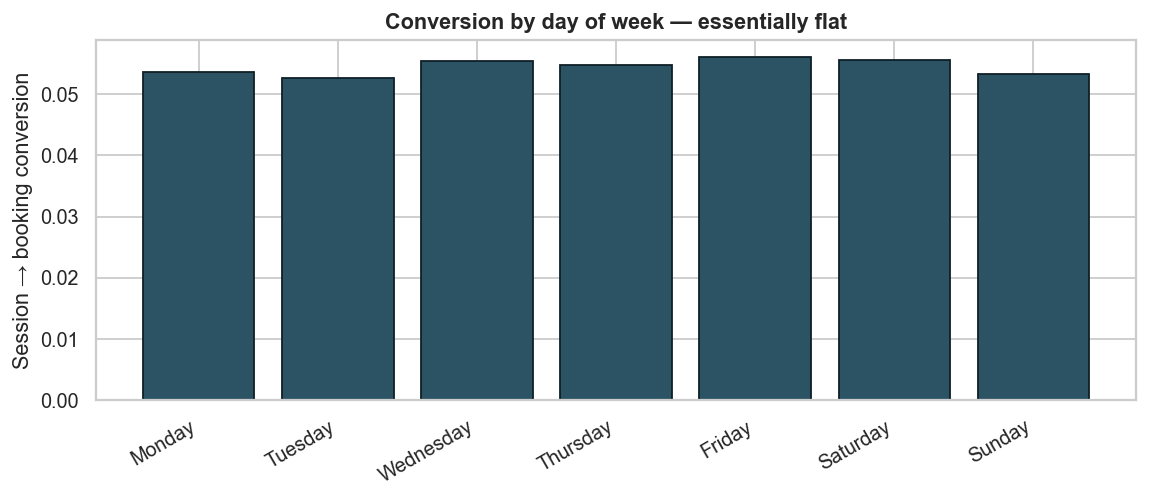

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dow.index, dow["mean"], color=PAL[2], edgecolor=PAL[0])
ax.set_title("Conversion by day of week — essentially flat")
ax.set_ylabel("Session → booking conversion")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig("visuals/11_dow_conversion.png", bbox_inches="tight")

## Bookings: following the money
Every dollar of the $1.25M GMV lives here. Distribution shape, outliers,
party sizes, and whether discounts actually change behavior.

In [8]:
print(bookings.gross_usd.describe().round(2).to_string())
q1, q3 = bookings.gross_usd.quantile([0.25, 0.75])
iqr = q3 - q1
out = ((bookings.gross_usd < q1 - 1.5 * iqr) | (bookings.gross_usd > q3 + 1.5 * iqr))
print(f"\nIQR outliers: {out.sum():,} ({out.mean():.1%} of bookings) — large party sizes, not errors.")
print(f"top 1% of bookings drive {(bookings.gross_usd.nlargest(int(len(bookings)*0.01)).sum() / bookings.gross_usd.sum()):.1%} of GMV")

count    6538.00
mean      214.51
std       158.12
min        18.57
25%       106.02
50%       170.61
75%       274.28
max      1374.30

IQR outliers: 327 (5.0% of bookings) — large party sizes, not errors.
top 1% of bookings drive 4.4% of GMV


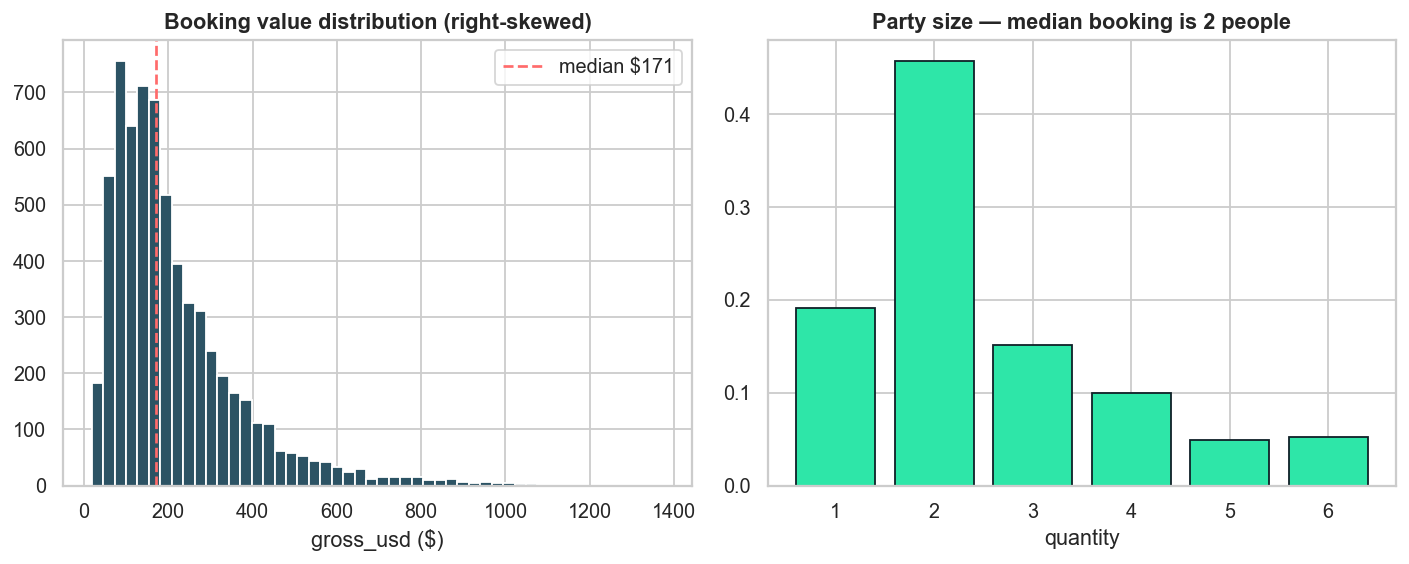

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(bookings.gross_usd, bins=50, color=PAL[2], edgecolor="white")
axes[0].axvline(bookings.gross_usd.median(), color=PAL[5], ls="--",
                label=f"median ${bookings.gross_usd.median():.0f}")
axes[0].set_title("Booking value distribution (right-skewed)")
axes[0].set_xlabel("gross_usd ($)")
axes[0].legend()
q = bookings.quantity.value_counts(normalize=True).sort_index()
axes[1].bar(q.index.astype(str), q.values, color=PAL[3], edgecolor=PAL[0])
axes[1].set_title("Party size — median booking is 2 people")
axes[1].set_xlabel("quantity")
fig.tight_layout()
fig.savefig("visuals/12_booking_value.png", bbox_inches="tight")

In [10]:
print(f"bookings with a discount: {(bookings.discount > 0).mean():.1%} (discounts run 0–{bookings.discount.max():.0%})")
print("\nstatus × discount (row %):")
print(pd.crosstab(bookings.status, bookings.discount > 0, normalize="index").round(3).to_string())
print("\nDiscounted bookings cancel at ~the same rate — discounts buy conversion, not loyalty.")

bookings with a discount: 29.3% (discounts run 0–20%)

status × discount (row %):
discount   False  True 
status                 
cancelled  0.702  0.298
completed  0.707  0.293
refunded   0.727  0.273

Discounted bookings cancel at ~the same rate — discounts buy conversion, not loyalty.


##  Users: acquisition vs. activation
8,000 users signed up. How many ever bought anything? The gap between
acquisition and activation is a product problem.

In [11]:
print("acquisition channel mix:")
print(users.acq_channel.value_counts().to_string())
print("\ntop countries:")
print(users.country.value_counts().head(8).to_string())
never = ~users.user_id.isin(bookings.user_id)
print(f"\nusers who never booked: {never.sum():,} / {len(users):,} ({never.mean():.1%})")
print("Over half of acquired users never convert — an activation problem, not just traffic.")

acquisition channel mix:
acq_channel
organic        2327
paid_search    1703
affiliates     1254
social         1192
referral        870
email           654

top countries:
country
UK           1267
US           1216
India         998
France        776
Germany       711
UAE           588
Singapore     586
Spain         471

users who never booked: 4,300 / 8,000 (53.8%)
Over half of acquired users never convert — an activation problem, not just traffic.


count    3700.00
mean        1.77
std         1.08
min         1.00
25%         1.00
50%         1.00
75%         2.00
max         8.00


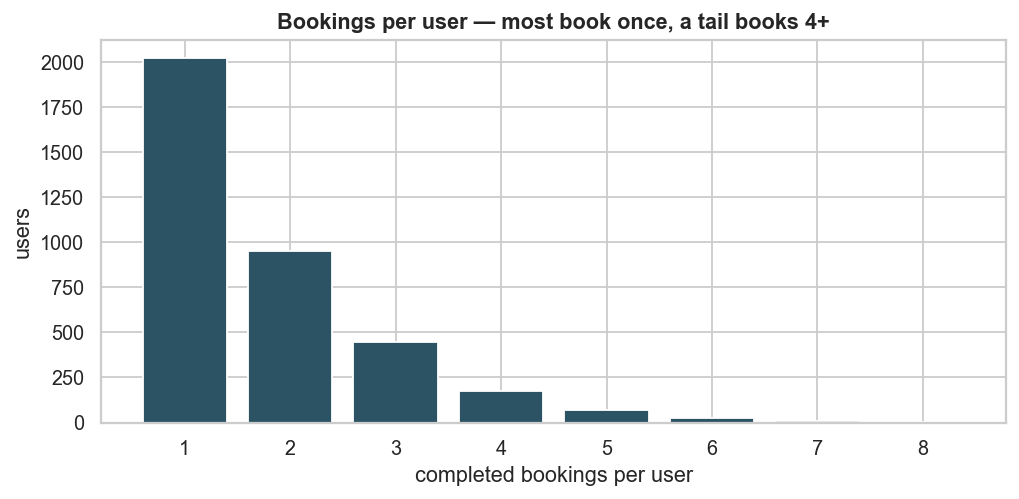

In [12]:
per_user = bookings.groupby("user_id").size()
print(per_user.describe().round(2).to_string())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_user.values, bins=range(1, per_user.max() + 2), color=PAL[2],
        edgecolor="white", align="left", rwidth=0.8)
ax.set_title("Bookings per user — most book once, a tail books 4+")
ax.set_xlabel("completed bookings per user")
ax.set_ylabel("users")
fig.tight_layout()
fig.savefig("visuals/13_bookings_per_user.png", bbox_inches="tight")

##  The catalog: experiences & suppliers
What are we actually selling? Price spread, rating quality, and which
categories carry the GMV.

In [13]:
print("categories:")
print(experiences.category.value_counts().to_string())
print("\nprice_usd:")
print(experiences.price_usd.describe().round(2).to_string())
print("\nrating:")
print(experiences.rating.describe().round(2).to_string())

categories:
category
Attraction Tickets    88
Guided Tours          64
Food Experiences      48
Day Trips             41
Shows & Musicals      36
Cruises               23

price_usd:
count    300.00
mean      88.38
std       40.16
min       25.07
25%       59.66
50%       81.60
75%      106.32
max      219.11

rating:
count    300.00
mean       4.49
std        0.25
min        3.80
25%        4.34
50%        4.50
75%        4.65
max        4.95


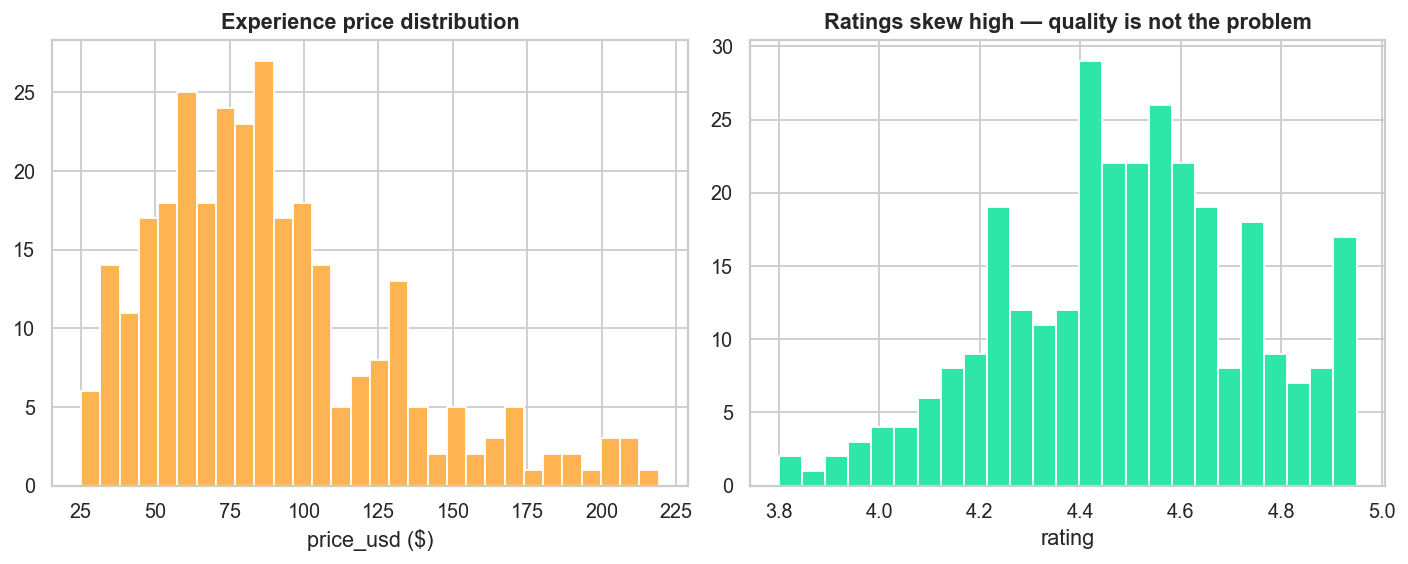

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(experiences.price_usd, bins=30, color=PAL[4], edgecolor="white")
axes[0].set_title("Experience price distribution")
axes[0].set_xlabel("price_usd ($)")
axes[1].hist(experiences.rating, bins=25, color=PAL[3], edgecolor="white")
axes[1].set_title("Ratings skew high — quality is not the problem")
axes[1].set_xlabel("rating")
fig.tight_layout()
fig.savefig("visuals/14_catalog.png", bbox_inches="tight")

In [15]:
cat_gmv = (completed.merge(experiences[["experience_id", "category"]], on="experience_id")
                    .groupby("category").gross_usd.sum().sort_values(ascending=False))
print("GMV share by category:")
print((cat_gmv / cat_gmv.sum()).apply("{:.1%}".format).to_string())
top1 = completed.groupby("experience_id").gross_usd.sum().nlargest(1)
print(f"\ntop single experience: ${top1.values[0]:,.0f} ({top1.values[0] / completed.gross_usd.sum():.1%} of GMV)")

GMV share by category:
category
Guided Tours          21.3%
Day Trips             20.4%
Attraction Tickets    19.2%
Shows & Musicals      14.1%
Food Experiences      13.6%
Cruises               11.4%

top single experience: $14,147 (1.1% of GMV)


##  KPI scorecard
Now the headline numbers — built on data we've already interrogated, so we
trust them.

In [16]:
gmv         = completed.gross_usd.sum()
n_book      = len(completed)
aov         = completed.gross_usd.mean()
sess_conv   = sessions.converted.mean()
cancel_rate = bookings.status.isin(["cancelled", "refunded"]).mean()
bookers     = completed.user_id.nunique()
repeat_rate = (completed.groupby("user_id").size() > 1).mean()
avg_lead    = (completed.travel_date - completed.booking_date).dt.days.mean()

In [17]:
kpi = pd.DataFrame([
    ("Completed bookings",            f"{n_book:,}"),
    ("Gross merchandise value (GMV)", f"${gmv:,.0f}"),
    ("Average order value",           f"${aov:,.2f}"),
    ("Session → booking conversion",  f"{sess_conv:.2%}"),
    ("Cancellation + refund rate",     f"{cancel_rate:.2%}"),
    ("Unique bookers",                f"{bookers:,}"),
    ("Repeat booker rate",            f"{repeat_rate:.1%}"),
    ("Avg booking lead time",         f"{avg_lead:.1f} days"),
], columns=["KPI", "Value"])
kpi.to_csv("kpi_summary.csv", index=False)
print(kpi.to_string(index=False))

                          KPI      Value
           Completed bookings      5,785
Gross merchandise value (GMV) $1,245,086
          Average order value    $215.23
 Session → booking conversion      5.45%
   Cancellation + refund rate     11.52%
               Unique bookers      3,452
           Repeat booker rate      42.0%
        Avg booking lead time  12.6 days


##  Demand trend
GMV and bookings by month. Demand builds into the year-end holiday peak —
the capacity-planning signal the supply team needs by Q3.

In [18]:
completed["month"] = completed.booking_date.dt.to_period("M").astype(str)
monthly = (completed.groupby("month")
                    .agg(gmv=("gross_usd", "sum"), bookings=("booking_id", "count"))
                    .reset_index())
monthly["mom_gmv"] = monthly.gmv.pct_change()
print(monthly.to_string(index=False, formatters={"gmv": "${:,.0f}".format, "mom_gmv": "{:.1%}".format}))
print(f"\nNov–Dec share of annual GMV: {monthly[monthly.month.isin(['2024-11','2024-12'])].gmv.sum() / monthly.gmv.sum():.1%}")

  month      gmv  bookings mom_gmv
2024-07 $114,726       524     NaN
2024-08 $102,798       468  -10.4%
2024-09 $109,102       501    6.1%
2024-10 $101,190       493   -7.3%
2024-11 $106,835       484    5.6%
2024-12 $101,853       485   -4.7%
2025-01 $104,061       481    2.2%
2025-02  $98,748       458   -5.1%
2025-03 $100,992       469    2.3%
2025-04 $107,495       499    6.4%
2025-05 $105,102       483   -2.2%
2025-06  $92,185       440  -12.3%

Nov–Dec share of annual GMV: 16.8%


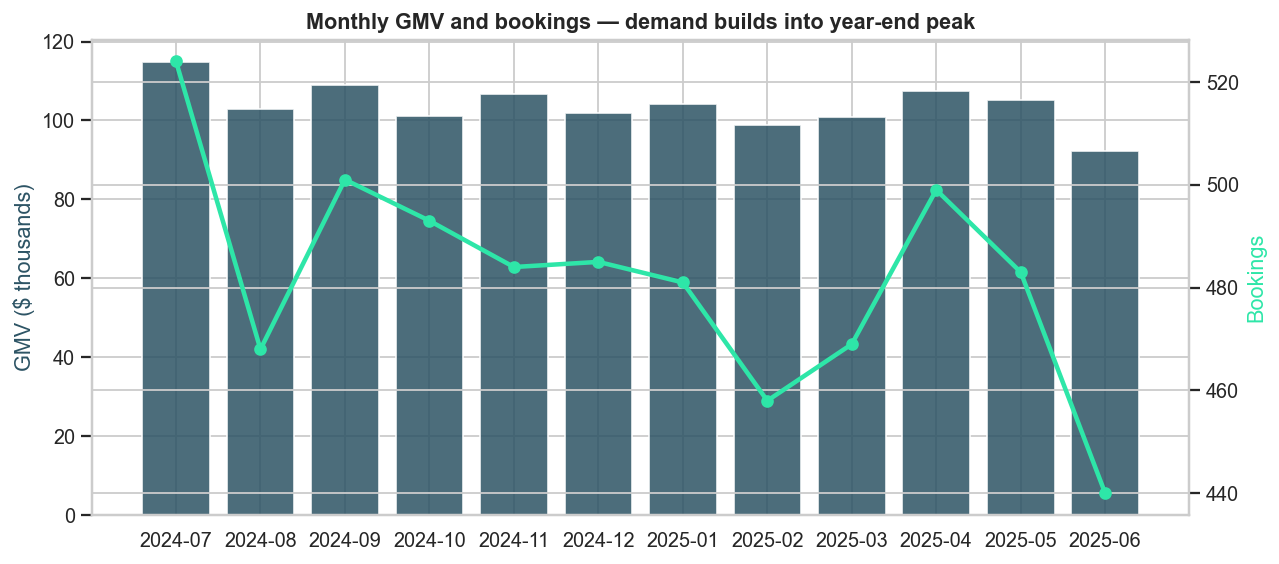

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.month, monthly.gmv / 1e3, color=PAL[2], alpha=0.85)
ax1.set_ylabel("GMV ($ thousands)", color=PAL[2])
ax2 = ax1.twinx()
ax2.plot(monthly.month, monthly.bookings, color=PAL[3], marker="o", linewidth=2.5)
ax2.set_ylabel("Bookings", color=PAL[3])
ax1.set_title("Monthly GMV and bookings — demand builds into year-end peak")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("visuals/01_monthly_gmv_bookings.png", bbox_inches="tight")

##  Conversion funnel
120k sessions traced through five stages. Step-to-step conversion exposes
exactly where intent dies.

In [20]:
funnel_n = [int((sessions.stage_reached.isin(STAGES[i:])).sum()) for i in range(5)]
step_conv = {f"{STAGES[i]} → {STAGES[i+1]}": funnel_n[i+1] / funnel_n[i] for i in range(4)}
for step, c in step_conv.items():
    print(f"{step:22s} {c:.1%}")

landing → listing      55.6%
listing → product      46.3%
product → checkout     36.3%
checkout → booked      58.3%


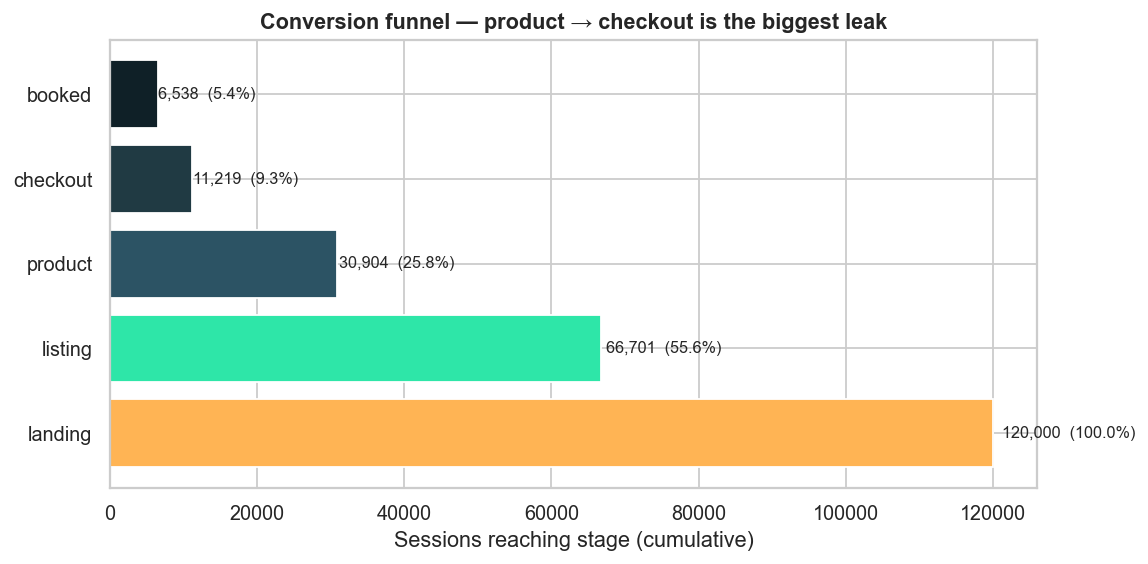

In [21]:
funnel_pct = [n / len(sessions) for n in funnel_n]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(STAGES, funnel_n, color=PAL[:5][::-1])
for bar, n, p in zip(bars, funnel_n, funnel_pct):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{n:,}  ({p:.1%})", va="center", fontsize=9)
ax.set_title("Conversion funnel — product → checkout is the biggest leak")
ax.set_xlabel("Sessions reaching stage (cumulative)")
fig.tight_layout()
fig.savefig("visuals/02_funnel.png", bbox_inches="tight")

##  Where the funnel breaks: channel
Which acquisition channels bring intent-rich traffic — and which bring tourists?

In [23]:
ch = sessions.groupby("channel").converted.agg(["mean", "count"]).reset_index()
ch = ch.sort_values("mean")
print(ch.to_string(index=False, formatters={"mean": "{:.2%}".format}))

    channel  mean  count
     social 2.00%  18133
 affiliates 3.95%  17958
    organic 4.90%  35991
   referral 6.08%  11965
      email 7.09%   9616
paid_search 8.70%  26337


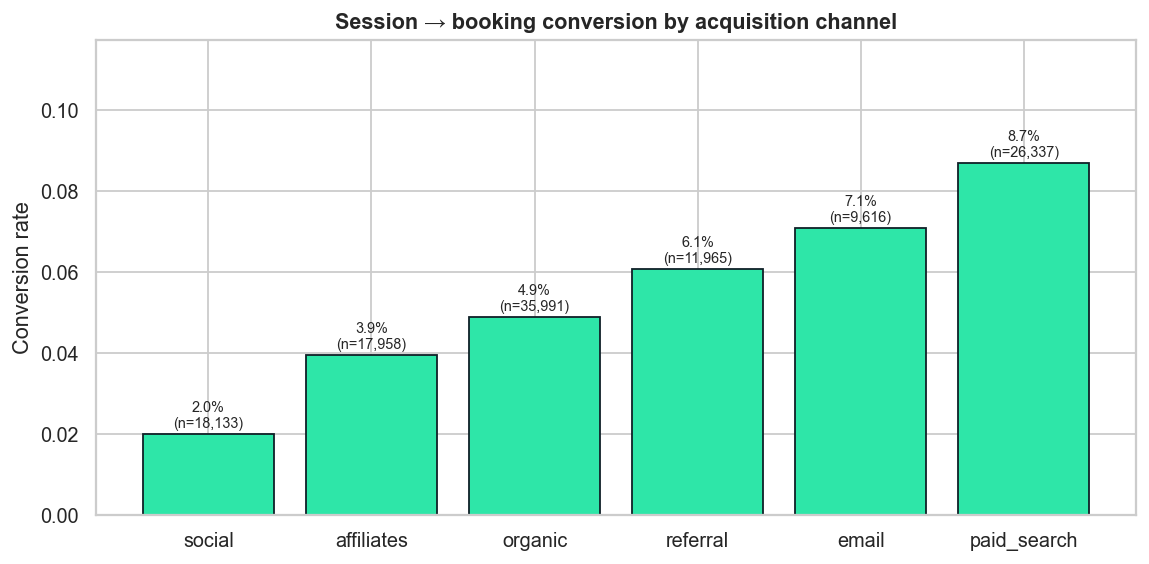

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(ch.channel, ch["mean"], color=PAL[3], edgecolor=PAL[0])
ax.set_ylim(0, ch["mean"].max() * 1.35)
for bar, v, n in zip(bars, ch["mean"], ch["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0015,
            f"{v:.1%}\n(n={n:,})", ha="center", fontsize=8)
ax.set_title("Session → booking conversion by acquisition channel")
ax.set_ylabel("Conversion rate")
fig.tight_layout()
fig.savefig("visuals/03_conversion_by_channel.png", bbox_inches="tight")

##  Where the funnel breaks: device
Mobile is most of the traffic. Does it convert?

In [25]:
dev = sessions.groupby("device").converted.agg(["mean", "count"]).reset_index()
print(dev.to_string(index=False, formatters={"mean": "{:.2%}".format}))

 device  mean  count
desktop 7.95%  36012
 mobile 4.32%  77928
 tablet 5.08%   6060


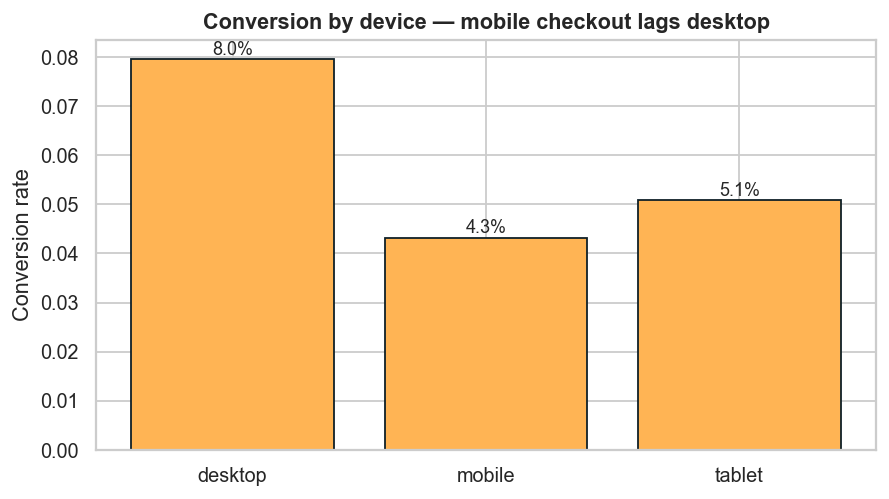

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dev.device, dev["mean"], color=PAL[4], edgecolor=PAL[0])
for bar, v in zip(ax.patches, dev["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{v:.1%}", ha="center", fontsize=10)
ax.set_title("Conversion by device — mobile checkout lags desktop")
ax.set_ylabel("Conversion rate")
fig.tight_layout()
fig.savefig("visuals/04_conversion_by_device.png", bbox_inches="tight")

##  Marketing attribution & ROAS
Revenue attributed to each channel vs. spend. ROAS below 1.0x destroys value.

In [27]:
attr = (completed.groupby("channel")
                 .agg(bookings=("booking_id", "count"), revenue=("gross_usd", "sum"))
                 .reset_index())
tot_spend = spend.groupby("channel").spend_usd.sum().reset_index()
attr = attr.merge(tot_spend, on="channel", how="left")
attr["roas"] = attr.revenue / attr.spend_usd.replace(0, np.nan)
attr = attr.sort_values("revenue", ascending=False)
print(attr.to_string(index=False,
      formatters={"revenue": "${:,.0f}".format, "spend_usd": "${:,.0f}".format, "roas": "{:.1f}x".format}))
waste = attr.loc[attr.channel == "social", "spend_usd"].values[0] * 0.5
print(f"\nCutting social 50% frees ${waste:,.0f}/yr to reallocate — bookings held constant.")

    channel  bookings  revenue spend_usd roas
paid_search      2017 $432,048  $216,000 2.0x
    organic      1576 $339,661        $0  NaN
   referral       646 $143,134        $0  NaN
 affiliates       626 $135,519   $72,000 1.9x
      email       596 $126,122   $24,000 5.3x
     social       324  $68,602  $144,000 0.5x

Cutting social 50% frees $72,000/yr to reallocate — bookings held constant.


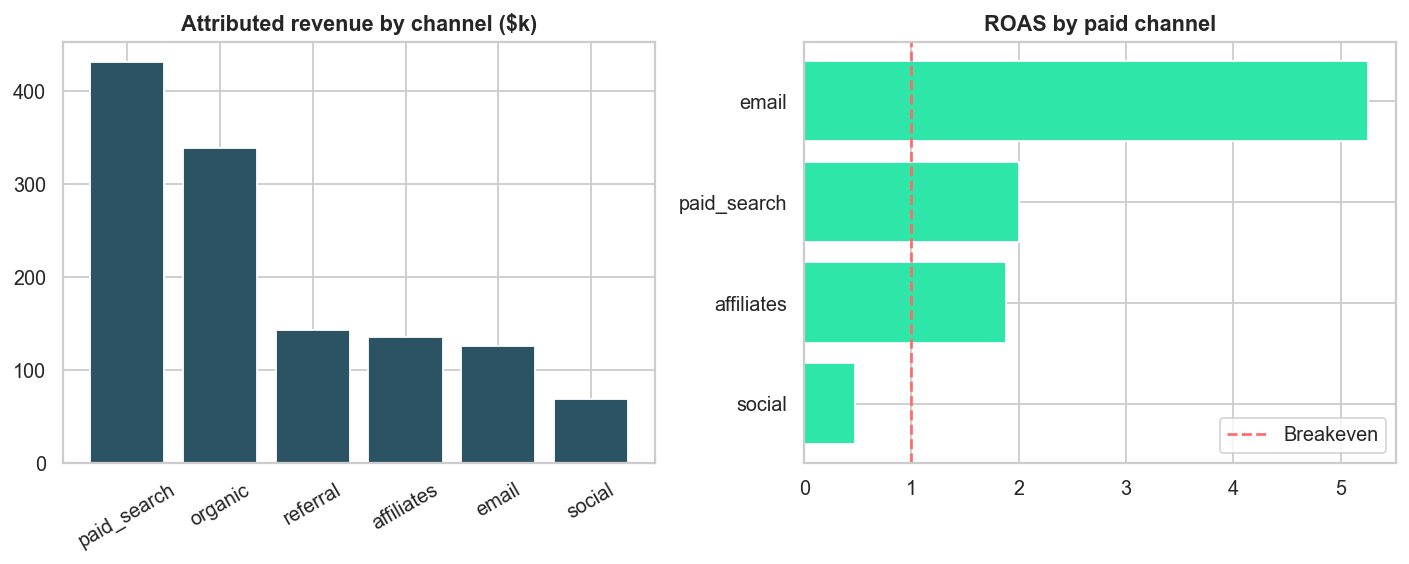

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(attr.channel, attr.revenue / 1e3, color=PAL[2])
axes[0].set_title("Attributed revenue by channel ($k)")
axes[0].tick_params(axis="x", rotation=30)
roas_plot = attr.dropna(subset=["roas"]).sort_values("roas")
axes[1].barh(roas_plot.channel, roas_plot.roas, color=PAL[3])
axes[1].axvline(1, color=PAL[5], linestyle="--", label="Breakeven")
axes[1].set_title("ROAS by paid channel")
axes[1].legend()
fig.tight_layout()
fig.savefig("visuals/05_attribution_roas.png", bbox_inches="tight")

## Supply-side economics
Are the best experiences starved of capacity? Utilization vs. rating, sized by GMV —
and which supplier tiers actually drive the marketplace.

In [29]:
exp_book = completed.groupby("experience_id").agg(qty=("quantity", "sum"),
                                                  gmv=("gross_usd", "sum")).reset_index()
exp2 = experiences.merge(exp_book, on="experience_id", how="left").fillna({"qty": 0, "gmv": 0})
exp2["utilization"] = exp2.qty / (exp2.capacity_per_day * 365)
sup_gmv = exp2.groupby("supplier_id").gmv.sum().reset_index()
sup2 = suppliers.merge(sup_gmv, on="supplier_id", how="left").fillna({"gmv": 0})
tier_share = sup2.groupby("tier").gmv.sum()
print((tier_share / tier_share.sum()).apply("{:.1%}".format).to_string())
print("\nSilver (50% of suppliers) drives",
      f"{tier_share['silver'] / tier_share.sum():.1%} of GMV — the long tail carries the marketplace.")

tier
gold        38.6%
platinum     7.9%
silver      53.5%

Silver (50% of suppliers) drives 53.5% of GMV — the long tail carries the marketplace.


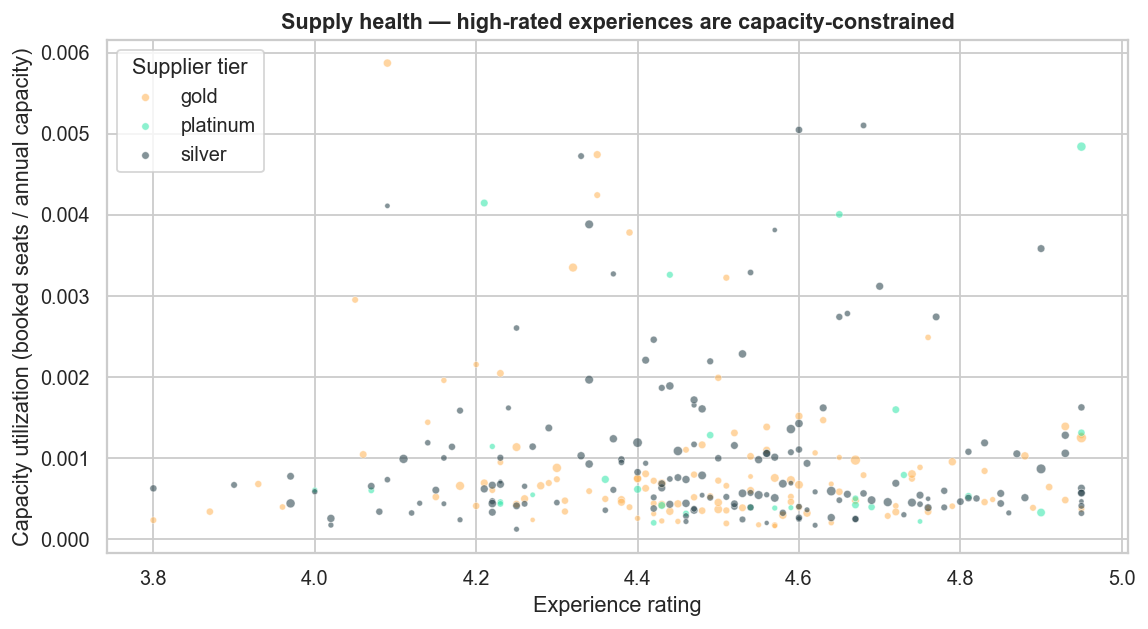

In [30]:
tier_color = {"platinum": PAL[3], "gold": PAL[4], "silver": PAL[1]}
exp2["tier"] = exp2.supplier_id.map(sup2.set_index("supplier_id").tier)
fig, ax = plt.subplots(figsize=(9, 5))
for tier, grp in exp2.groupby("tier"):
    ax.scatter(grp.rating, grp.utilization, s=np.sqrt(grp.gmv) / 4,
               c=tier_color[tier], alpha=0.55, label=tier,
               edgecolors="white", linewidths=0.4)
ax.set_xlabel("Experience rating")
ax.set_ylabel("Capacity utilization (booked seats / annual capacity)")
ax.set_title("Supply health — high-rated experiences are capacity-constrained")
ax.legend(title="Supplier tier")
fig.tight_layout()
fig.savefig("visuals/06_supply_utilization.png", bbox_inches="tight")

##  Booking lead time
How far ahead do people book? Short lead times mean demand is impulse-driven —
retargeting windows should be measured in days, not weeks.

In [31]:
completed["lead_days"] = (completed.travel_date - completed.booking_date).dt.days
print(f"median lead time: {completed.lead_days.median():.0f} days")
print(f"mean lead time:   {completed.lead_days.mean():.1f} days")
print(f"booked < 3 weeks out: {(completed.lead_days < 21).mean():.1%}")

median lead time: 9 days
mean lead time:   12.6 days
booked < 3 weeks out: 80.9%


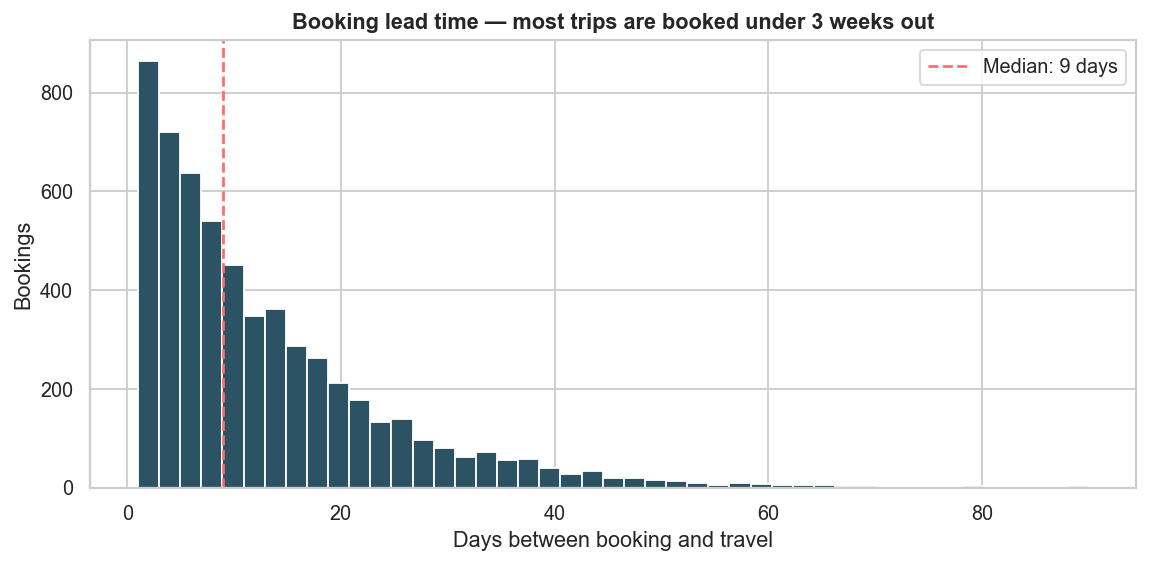

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(completed.lead_days, bins=45, color=PAL[2], edgecolor="white")
ax.axvline(completed.lead_days.median(), color=PAL[5], linestyle="--",
           label=f"Median: {completed.lead_days.median():.0f} days")
ax.set_title("Booking lead time — most trips are booked under 3 weeks out")
ax.set_xlabel("Days between booking and travel")
ax.set_ylabel("Bookings")
ax.legend()
fig.tight_layout()
fig.savefig("visuals/07_lead_time.png", bbox_inches="tight")

## 15. A/B test readout: free-cancellation badge
Product-page test, n = 8,000/arm, 28 days. Two-proportion z-test with a 95% CI.

In [33]:
g = (experiment.groupby("variant")
               .agg(n=("converted", "size"), conv=("converted", "mean"),
                    rev=("revenue_usd", "sum")).reset_index())
a, b = g[g.variant == "A"].iloc[0], g[g.variant == "B"].iloc[0]
p_pool = (a.conv * a.n + b.conv * b.n) / (a.n + b.n)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / a.n + 1 / b.n))
z = (b.conv - a.conv) / se
from math import erf
p_val = 2 * (1 - 0.5 * (1 + erf(abs(z) / np.sqrt(2))))
lift = (b.conv - a.conv) / a.conv
ci = 1.96 * np.sqrt(a.conv * (1 - a.conv) / a.n + b.conv * (1 - b.conv) / b.n)
print(f"A (control):   {a.conv:.2%}  (n={a.n:,})")
print(f"B (treatment): {b.conv:.2%}  (n={b.n:,})")
print(f"lift {lift:+.1%}   z={z:.2f}   p={p_val:.4f}   95% CI [{b.conv - a.conv - ci:+.2%}, {b.conv - a.conv + ci:+.2%}]")

A (control):   4.78%  (n=8,000)
B (treatment): 5.85%  (n=8,000)
lift +22.5%   z=3.03   p=0.0024   95% CI [+0.38%, +1.77%]


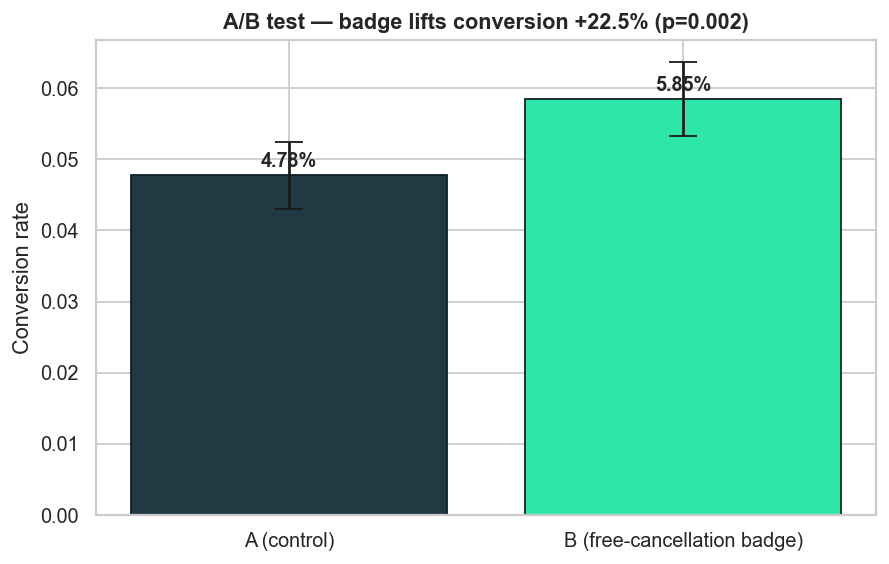

In [34]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = ["A (control)", "B (free-cancellation badge)"]
vals = [a.conv, b.conv]
err = [1.96 * np.sqrt(v * (1 - v) / n) for v, n in [(a.conv, a.n), (b.conv, b.n)]]
bars = ax.bar(x, vals, yerr=err, capsize=8, color=[PAL[1], PAL[3]], edgecolor=PAL[0])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0012,
            f"{v:.2%}", ha="center", fontsize=11, fontweight="bold")
ax.set_title(f"A/B test — badge lifts conversion {lift:+.1%} (p={p_val:.3f})")
ax.set_ylabel("Conversion rate")
fig.tight_layout()
fig.savefig("visuals/08_experiment.png", bbox_inches="tight")

## 16. Experiment rigor: SRM check + power
A significant p-value means nothing if the randomization broke. The SRM check
(chi-square on the 50/50 allocation) and a minimum-detectable-effect sanity check
run *before* any ship decision.

In [35]:
obs = experiment.variant.value_counts().sort_index().values
exp_n = len(experiment) / 2
chi2 = ((obs - exp_n) ** 2 / exp_n).sum()   # df=1, critical value 3.84 at alpha=5%
p0 = experiment.loc[experiment.variant == "A", "converted"].mean()
n_arm = (experiment.variant == "A").sum()
mde = (1.96 + 0.84) * np.sqrt(2 * p0 * (1 - p0) / n_arm)  # 80% power, alpha=5%
lift_pp = experiment.loc[experiment.variant == "B", "converted"].mean() - p0
print(f"allocation A/B = {obs[0]:,}/{obs[1]:,}  SRM chi2={chi2:.3f} "
      + ("(clean — no mismatch)" if chi2 < 3.84 else "(SRM DETECTED — stop!)"))
print(f"baseline={p0:.2%}  MDE(80% power)={mde:.2%}  observed lift={lift_pp:+.2%}")
print("Observed lift exceeds MDE and allocation is clean → the +22.5% is trustworthy.")

allocation A/B = 8,000/8,000  SRM chi2=0.000 (clean — no mismatch)
baseline=4.78%  MDE(80% power)=0.94%  observed lift=+1.08%
Observed lift exceeds MDE and allocation is clean → the +22.5% is trustworthy.


## 17. Cohort retention
Acquisition is only half the marketplace equation. Repeat-booker rate by signup
cohort shows whether the product earns a second purchase.

In [36]:
n_book = completed.groupby("user_id").size().rename("n_bookings")
coh = users.copy()
coh["cohort"] = coh.signup_date.dt.to_period("M").astype(str)
coh = coh.merge(n_book, on="user_id", how="left").fillna({"n_bookings": 0})
coh["is_repeat"] = (coh.n_bookings >= 2).astype(int)
coh_ret = (coh.groupby("cohort")
              .agg(users=("user_id", "count"), repeat_rate=("is_repeat", "mean"))
              .reset_index())
print(f"overall repeat-booker rate: {coh.is_repeat.mean():.1%}")
print(coh_ret.to_string(index=False, formatters={"repeat_rate": "{:.1%}".format}))

overall repeat-booker rate: 18.1%
 cohort  users repeat_rate
2023-06    311       17.0%
2023-07    335       14.9%
2023-08    308       19.2%
2023-09    332       20.8%
2023-10    327       19.0%
2023-11    303       17.5%
2023-12    344       19.8%
2024-01    362       16.3%
2024-02    331       17.8%
2024-03    278       18.3%
2024-04    321       18.1%
2024-05    343       18.4%
2024-06    319       15.4%
2024-07    346       17.1%
2024-08    323       18.3%
2024-09    312       18.9%
2024-10    344       17.2%
2024-11    302       16.6%
2024-12    350       17.1%
2025-01    305       15.7%
2025-02    282       20.6%
2025-03    337       20.5%
2025-04    288       20.1%
2025-05    305       18.0%
2025-06    292       21.6%


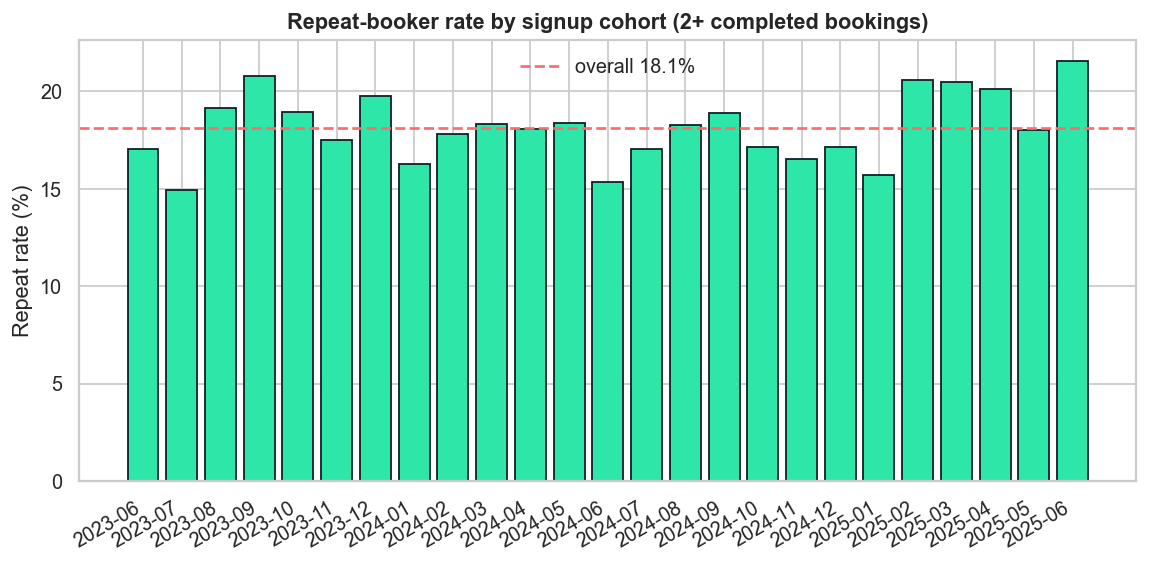

In [37]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(coh_ret.cohort, coh_ret.repeat_rate * 100, color=PAL[3], edgecolor="#0f2027")
ax.axhline(coh.is_repeat.mean() * 100, color="#FF6B6B", ls="--", lw=1.5,
           label=f"overall {coh.is_repeat.mean():.1%}")
ax.set_title("Repeat-booker rate by signup cohort (2+ completed bookings)")
ax.set_ylabel("Repeat rate (%)")
ax.legend(frameon=False)
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig("visuals/10_cohort_retention.png", bbox_inches="tight")

## 18. Segment deep-dive: quantifying the mobile checkout leak
The funnel said product → checkout is the biggest leak, and mobile converts below
desktop. Crossing the two tells us exactly how much of the leak is a mobile UX problem.

In [38]:
s = sessions.copy()
s["ord"] = s.stage_reached.map({st: i for i, st in enumerate(STAGES)})
pv = s[s.ord >= 2]  # reached the product page
leak = (pv.groupby("device")
          .agg(viewed=("session_id", "count"),
               reached_checkout=("ord", lambda x: (x >= 3).sum())))
leak["checkout_rate"] = leak.reached_checkout / leak.viewed
leak["lost_at_step"] = leak.viewed - leak.reached_checkout
print(leak[["viewed", "reached_checkout", "lost_at_step"]].to_string())
print("\ncheckout_rate by device:")
print(((leak.checkout_rate * 100).round(1).astype(str) + "%").to_string())
mobile_lost = int(leak.loc["mobile", "lost_at_step"])
print(f"\nMobile sessions dying at product → checkout: {mobile_lost:,}")
print("That is the single largest addressable pool of lost intent in the funnel.")

         viewed  reached_checkout  lost_at_step
device                                         
desktop   11153              4453          6700
mobile    18207              6220         11987
tablet     1544               546           998

checkout_rate by device:
device
desktop    39.9%
mobile     34.2%
tablet     35.4%

Mobile sessions dying at product → checkout: 11,987
That is the single largest addressable pool of lost intent in the funnel.


## 19. Geographic mix
No single city dominates GMV — healthy diversification, at the cost of managing
8 separate supply relationships.

In [39]:
city = completed.merge(experiences[["experience_id", "city"]], on="experience_id")
city_gmv = city.groupby("city").gross_usd.sum().sort_values(ascending=False)
print((city_gmv / city_gmv.sum()).apply("{:.1%}".format).to_string())

city
Singapore    14.7%
Rome         14.4%
Paris        14.3%
Dubai        12.4%
New York     12.0%
Tokyo        11.4%
London       11.1%
Barcelona     9.6%


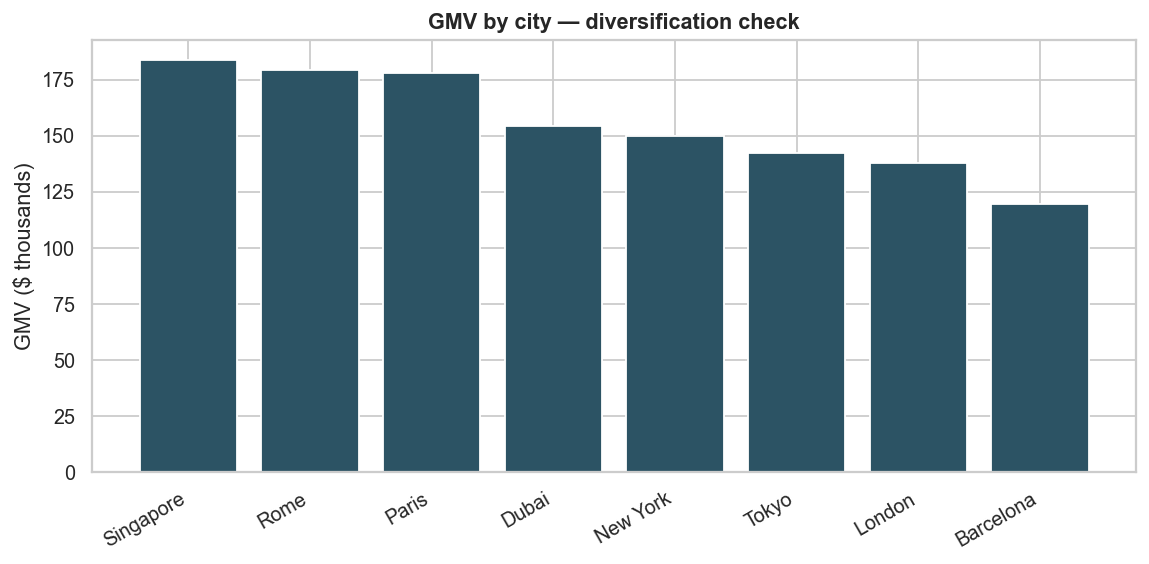

In [40]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(city_gmv.index, city_gmv.values / 1e3, color=PAL[2])
ax.set_title("GMV by city — diversification check")
ax.set_ylabel("GMV ($ thousands)")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig("visuals/09_city_gmv.png", bbox_inches="tight")

## 20. Recommendations (prioritized)

1. **Fix the product → checkout leak.** At 36.3%, this single step costs more bookings than any
   channel optimization. The deep-dive shows ~12k mobile sessions dying here — prioritize mobile
   checkout UX (mobile = 65% of traffic).
2. **Reallocate social budget.** Social ROAS is 0.5x — cut spend 50% and move it to email (5.3x ROAS)
   and paid search (2.0x). Expected impact: same bookings at ~$60k lower annual spend.
3. **Ship the free-cancellation badge.** +22.5% conversion lift, p = 0.002, SRM-clean, powered
   (MDE 0.94pp < observed 1.08pp). At current traffic this is worth roughly +1,500 bookings/year.
   Guardrail post-ship: net completed bookings, not gross conversion.
4. **Unlock constrained supply.** High-rated, high-utilization experiences need more capacity or
   dynamic pricing — unfulfilled demand is invisible in GMV but real.
5. **Attack the 11.5% cancellation rate — and the 54% never-booked users.** With median 12.6-day
   lead times, a 48-hour pre-travel nudge rescues margin; a separate onboarding track should
   convert the acquired-but-inactive majority.

